In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("/Users/vrund/Desktop/Projects/Loan Eligibility Prediction/LoanApprovalPrediction.csv")

In [3]:
data.head(5)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
data.sample(15)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
289,LP001949,Male,Yes,3.0,Graduate,Yes,4416,1250.0,110.0,360.0,1.0,Urban,Y
533,LP002768,Male,No,0.0,Not Graduate,No,3358,0.0,80.0,36.0,1.0,Semiurban,N
221,LP001754,Male,Yes,NaN,Not Graduate,Yes,4735,0.0,138.0,360.0,1.0,Urban,N
323,LP002097,Male,No,1.0,Graduate,No,4384,1793.0,117.0,360.0,1.0,Urban,Y
488,LP002603,Female,No,0.0,Graduate,No,645,3683.0,113.0,480.0,1.0,Rural,Y
262,LP001883,Female,No,0.0,Graduate,Yes,3418,0.0,135.0,360.0,1.0,Rural,N
360,LP002190,Male,Yes,1.0,Graduate,No,6325,0.0,175.0,360.0,1.0,Semiurban,Y
251,LP001854,Male,Yes,3.0,Graduate,No,5250,0.0,94.0,360.0,1.0,Urban,N
299,LP001990,Male,No,0.0,Not Graduate,No,2000,0.0,NaN,360.0,1.0,Urban,N
510,LP002693,Male,Yes,2.0,Graduate,Yes,7948,7166.0,480.0,360.0,1.0,Rural,Y


In [7]:
data["Loan_Amount_Term"].unique()

array([360., 120., 240.,  nan, 180.,  60., 300., 480.,  36.,  84.,  12.])

In [9]:
obj_cols = list(data.columns[data.dtypes == 'object'])
print("Categorical variables:",len(object_cols))

NameError: name 'object_cols' is not defined

In [11]:
#    another way to find the column with data type 'object'

#  obj = (data.dtypes == 'object')
#  print("Categorical variables:",len(list(obj[obj].index)))

In [13]:
data.drop(['Loan_ID'],axis = 1,inplace=True)

In [15]:
obj = (data.dtypes == 'object')
obj

Gender                True
Married               True
Dependents           False
Education             True
Self_Employed         True
ApplicantIncome      False
CoapplicantIncome    False
LoanAmount           False
Loan_Amount_Term     False
Credit_History       False
Property_Area         True
Loan_Status           True
dtype: bool

In [17]:
# obj = (data.dtypes == 'object')
# object_cols = list(obj[obj].index)

In [19]:
# data['Gender'].value_counts()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/opt/anacond

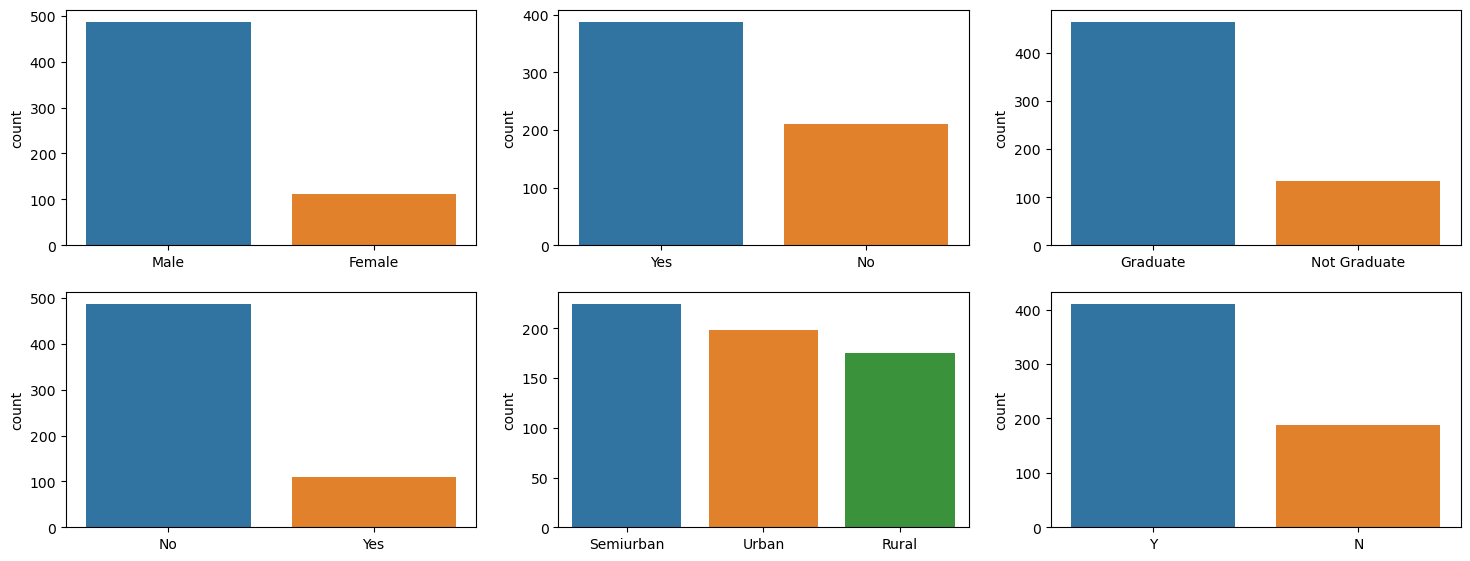

In [21]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.figure(figsize=(18,36))
index = 1

for col in object_cols:
  y = data[col].value_counts()
  plt.subplot(10,3,index)
  plt.xticks(rotation=0)
  sns.barplot(x=list(y.index), y=y)
  index +=1

In [23]:
# Import label encoder
from sklearn import preprocessing

# label_encoder object knows how
# to understand word labels.
label_encoder = preprocessing.LabelEncoder()
obj = (data.dtypes == 'object')
for col in list(obj[obj].index):
  data[col] = label_encoder.fit_transform(data[col])

In [25]:
# To find the number of columns with
# datatype==object
obj = (data.dtypes == 'object')
print("Categorical variables:",len(list(obj[obj].index)))

Categorical variables: 0


In [27]:
data['Property_Area']

0      2
1      0
2      2
3      2
4      2
      ..
593    0
594    0
595    2
596    2
597    1
Name: Property_Area, Length: 598, dtype: int64

In [29]:
data['Property_Area'].unique()

array([2, 0, 1])

In [31]:
data['LoanAmount']

0        NaN
1      128.0
2       66.0
3      120.0
4      141.0
       ...  
593     71.0
594     40.0
595    253.0
596    187.0
597    133.0
Name: LoanAmount, Length: 598, dtype: float64

In [33]:
data['LoanAmount'].value_counts()

LoanAmount
120.0    20
110.0    16
100.0    15
187.0    12
128.0    11
         ..
72.0      1
240.0     1
214.0     1
59.0      1
253.0     1
Name: count, Length: 199, dtype: int64

In [35]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             598 non-null    int64  
 1   Married            598 non-null    int64  
 2   Dependents         586 non-null    float64
 3   Education          598 non-null    int64  
 4   Self_Employed      598 non-null    int64  
 5   ApplicantIncome    598 non-null    int64  
 6   CoapplicantIncome  598 non-null    float64
 7   LoanAmount         577 non-null    float64
 8   Loan_Amount_Term   584 non-null    float64
 9   Credit_History     549 non-null    float64
 10  Property_Area      598 non-null    int64  
 11  Loan_Status        598 non-null    int64  
dtypes: float64(5), int64(7)
memory usage: 56.2 KB


In [39]:
data.sample(5)

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
588,0,1,1.0,0,0,12000,0.0,496.0,360.0,1.0,1,1
94,1,0,0.0,0,1,6782,0.0,NaN,360.0,NaN,2,0
368,1,1,3.0,0,0,8750,4996.0,130.0,360.0,1.0,0,1
176,1,1,1.0,0,0,6400,7250.0,180.0,360.0,0.0,2,0
567,1,0,0.0,0,0,1836,33837.0,90.0,360.0,1.0,2,0


<Axes: >

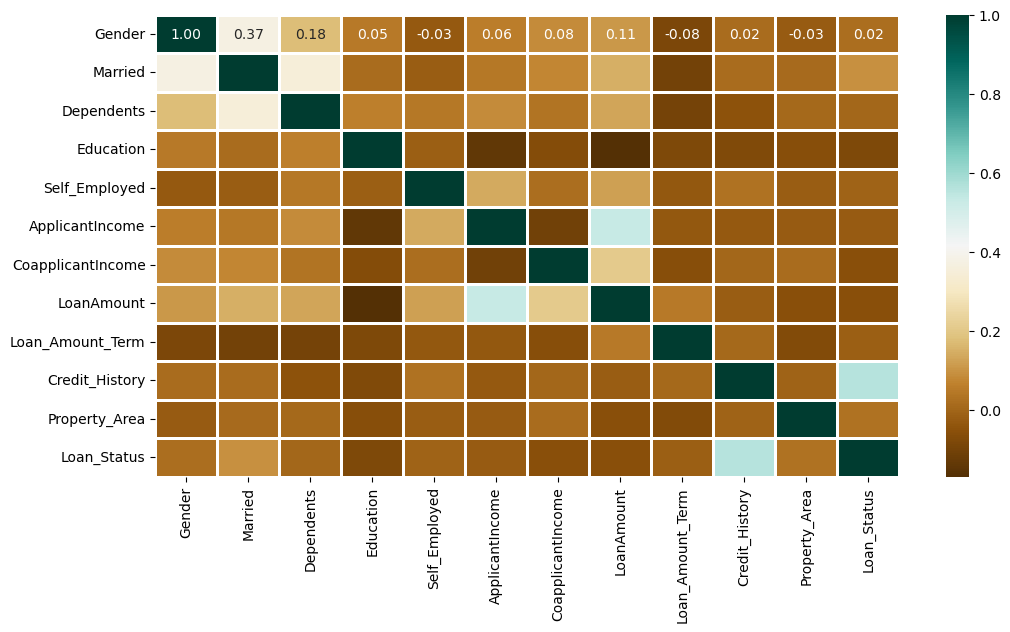

In [41]:
plt.figure(figsize=(12,6))

sns.heatmap(data.corr(),cmap='BrBG',fmt='.2f',
            linewidths=2,annot=True)

AttributeError: 'numpy.int64' object has no attribute 'startswith'

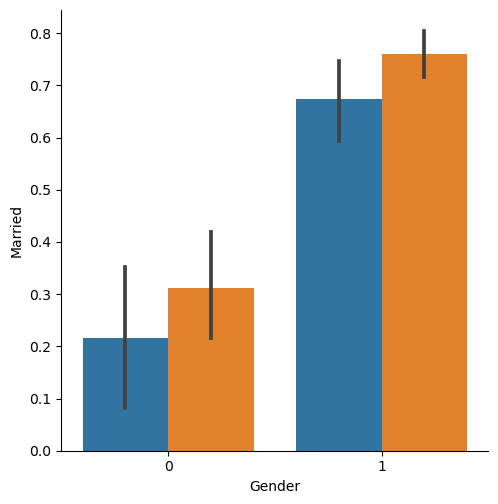

In [43]:
sns.catplot(x="Gender", y="Married",
            hue="Loan_Status",
            kind="bar",
            data=data)

In [47]:
data.isna().sum()

Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [49]:
for col in data.columns:
  data[col] = data[col].fillna(data[col].mean())
data.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [51]:
from sklearn.model_selection import train_test_split

X = data.drop(['Loan_Status'],axis=1)
Y = data['Loan_Status']
X.shape,Y.shape

((598, 11), (598,))

In [53]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.4,
                                                    random_state=1)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((358, 11), (240, 11), (358,), (240,))

In [57]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn import metrics

knn = KNeighborsClassifier(n_neighbors=3)
rfc = RandomForestClassifier(n_estimators = 7,
                             criterion = 'entropy',
                             random_state =7)
svm = SVC()
lr = LogisticRegression()

# making predictions on the training set
for clf in (rfc, knn, svm,lr):
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_train)
    print("Accuracy score of",
          clf.__class__.__name__,
          "=",100*metrics.accuracy_score(Y_train,
                                         Y_pred))

Accuracy score of RandomForestClassifier = 98.04469273743017
Accuracy score of KNeighborsClassifier = 78.49162011173185
Accuracy score of SVC = 68.71508379888269
Accuracy score of LogisticRegression = 80.44692737430168


In [59]:
# making predictions on the testing set
for clf in (rfc, knn, svm,lr):
    clf.fit(X_train, Y_train)
    Y_pred = clf.predict(X_test)
    print("Accuracy score of",
          clf.__class__.__name__,"=",
          100*metrics.accuracy_score(Y_test,
                                     Y_pred))

Accuracy score of RandomForestClassifier = 82.5
Accuracy score of KNeighborsClassifier = 63.74999999999999
Accuracy score of SVC = 69.16666666666667
Accuracy score of LogisticRegression = 80.83333333333333


In [136]:
import pickle
pickle.dump(rfc, open("loan_model_RF.pkl", "wb"))

In [138]:
pickle.dump(knn, open("loan_model_KNN.pkl","wb"))
pickle.dump(svm, open("loan_model_SVC.pkl","wb"))
pickle.dump(lr, open("loan_model_LR.pkl","wb"))